<a href="https://colab.research.google.com/github/debashistripathy-riku/LMS_celebal_weekly_Assignment/blob/main/week4_DEBASHIS_TRIPATHY_SOA_University.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook contains the complete solution for building and comparing ANN and CNN models on the CIFAR-10 image classification task, including data augmentation, wider layers, scaled filter sizes, 20 epochs training, and early stopping.

# 🧠 Setup & Imports

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load CIFAR-10 Dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3729s 22us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

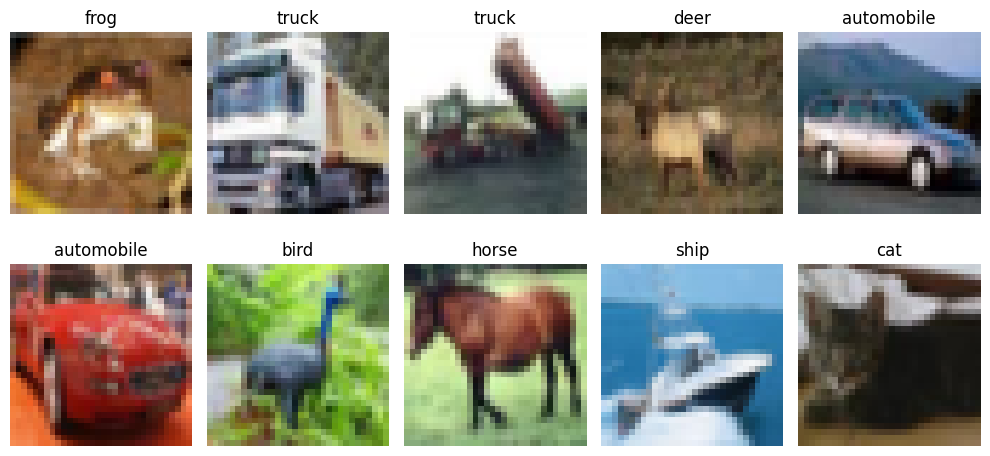

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
Normalize raw image channel pixel integers (0-255 -> 0-1.0) to stabilize gradient updates.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)
print("Flat train shape:", x_train_flat.shape)

Flat train shape: (50000, 3072)


# 🔹 Part 1: Baseline ANN Model
Build a baseline ANN model on flat vectors using Dense and Dropout layers.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.2667 - loss: 2.0012 - val_accuracy: 0.3298 - val_loss: 1.8459
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.3158 - loss: 1.8778 - val_accuracy: 0.3622 - val_loss: 1.8069
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.3345 - loss: 1.8278 - val_accuracy: 0.3826 - val_loss: 1.7557
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3468 - loss: 1.7906 - val_accuracy: 0.3898 - val_loss: 1.7220
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.3597 - loss: 1.7626 - val_accuracy: 0.3864 - val_loss: 1.7235
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.3685 - loss: 1.7408 - val_accuracy: 0.4104 - val_loss: 1.6815
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.3793 - loss: 1.7211 - val_accuracy: 0.3944 - val_loss: 1.6941
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.3818 - loss: 1.7100 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4197 - loss: 1.6385
ANN Test Accuracy: 0.4196999967098236


# 🔹 Part 2: Baseline CNN Model
Build a spatial CNN architecture using Conv2D, BatchNormalization, MaxPooling2D, Flatten, and dense classification layers.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 107ms/step - accuracy: 0.4614 - loss: 1.5099 - val_accuracy: 0.4864 - val_loss: 1.4240
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 106ms/step - accuracy: 0.6088 - loss: 1.1204 - val_accuracy: 0.5722 - val_loss: 1.1956
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 107ms/step - accuracy: 0.6704 - loss: 0.9523 - val_accuracy: 0.6184 - val_loss: 1.1156
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 106ms/step - accuracy: 0.7093 - loss: 0.8359 - val_accuracy: 0.6366 - val_loss: 1.0803
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 106ms/step - accuracy: 0.7435 - loss: 0.7375 - val_accuracy: 0.6756 - val_loss: 0.9755
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 105ms/step - accuracy: 0.7705 - loss: 0.6573 - val_accuracy: 0.7036 - val_loss: 0.8868
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 106ms/step - accuracy: 0.7887 - loss: 0.5993 - val_accuracy: 0.6538 - val_loss: 1.1904
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.8107 - loss: 0

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7306 - loss: 0.9018
CNN Test Accuracy: 0.7305999994277954


## 📈 Compare Learning Curves (Overlapping Chart over 10 Epochs)

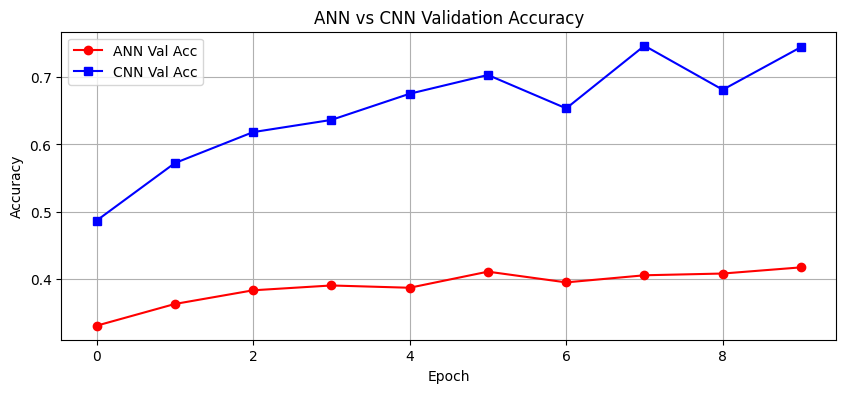

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], 'r-o', label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], 'b-s', label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# 🎓 Fully Implemented Student Learning Tasks (Beginner Tasks)

Here are the code answers addressing all 5 beginner tasks.

### ✅ Task 1: Increase ANN Dense Layout Configurations

In [ ]:
# Task 1: Increased density to 1024 -> 512 -> 256 layout
ann_upgraded = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

ann_upgraded.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Task 4: Integrate EarlyStopping
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

# Task 3: Increase training to 20 epochs
ann_upgraded_history = ann_upgraded.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 57ms/step - accuracy: 0.2252 - loss: 2.0750 - val_accuracy: 0.2596 - val_loss: 1.9550
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.2722 - loss: 1.9578 - val_accuracy: 0.3080 - val_loss: 1.8986
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.2898 - loss: 1.9146 - val_accuracy: 0.3404 - val_loss: 1.8739
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 58ms/step - accuracy: 0.3054 - loss: 1.8874 - val_accuracy: 0.3482 - val_loss: 1.8424
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.3126 - loss: 1.8684 - val_accuracy: 0.3382 - val_loss: 1.8509
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.3188 - loss: 1.8545 - val_accuracy: 0.3494 - val_loss: 1.8356
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.3254 - loss: 1.8355 - val_accuracy: 0.3610 - val_loss: 1.8128
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.3347 - loss: 1.8236 - 

In [ ]:
ann_upg_loss, ann_upg_acc = ann_upgraded.evaluate(x_test_flat, y_test)
print("Upgraded ANN Test Accuracy:", ann_upg_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4130 - loss: 1.7022
Upgraded ANN Test Accuracy: 0.4129999876022339


### ✅ Task 2: Scale up CNN filters (32 → 64 → 128)

In [ ]:
# Task 2: CNN scaled filter sizes 32 -> 64 -> 128 with batch norm and dense layout (256)
cnn_upgraded = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_upgraded.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train for 20 epochs with early stopping
cnn_upgraded_history = cnn_upgraded.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 112ms/step - accuracy: 0.4974 - loss: 1.4097 - val_accuracy: 0.5600 - val_loss: 1.2148
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 111ms/step - accuracy: 0.6364 - loss: 1.0358 - val_accuracy: 0.5798 - val_loss: 1.2474
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.6980 - loss: 0.8640 - val_accuracy: 0.6938 - val_loss: 0.8971
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 111ms/step - accuracy: 0.7412 - loss: 0.7402 - val_accuracy: 0.6934 - val_loss: 0.9022
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 111ms/step - accuracy: 0.7734 - loss: 0.6479 - val_accuracy: 0.7316 - val_loss: 0.8125
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.8024 - loss: 0.5565 - val_accuracy: 0.6630 - val_loss: 1.1399
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.8281 - loss: 0.4842 - val_accuracy: 0.7182 - val_loss: 0.9098
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 111ms/step - accuracy: 0.8470 - loss: 0

In [ ]:
cnn_upg_loss, cnn_upg_acc = cnn_upgraded.evaluate(x_test_norm, y_test)
print("Upgraded CNN Test Accuracy:", cnn_upg_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7163 - loss: 0.8530
Upgraded CNN Test Accuracy: 0.7163000106811523


### ✅ Task 5: Execute augmented network training run

In [ ]:
# Task 5: Training of Augmented CNN Model for 20 epochs with EarlyStopping
cnn_augmented = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_augmented.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_augmented_history = cnn_augmented.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 103s 142ms/step - accuracy: 0.4244 - loss: 1.6145 - val_accuracy: 0.5184 - val_loss: 1.3460
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 136ms/step - accuracy: 0.5229 - loss: 1.3468 - val_accuracy: 0.5748 - val_loss: 1.2276
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 137ms/step - accuracy: 0.5688 - loss: 1.2243 - val_accuracy: 0.6350 - val_loss: 1.0260
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 136ms/step - accuracy: 0.5982 - loss: 1.1479 - val_accuracy: 0.6090 - val_loss: 1.0992


In [ ]:
cnn_aug_loss, cnn_aug_acc = cnn_augmented.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", cnn_aug_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5193 - loss: 1.3539
Augmented CNN Test Accuracy: 0.5192999839782715


# 📊 Comparison Curves (All 5 configurations)

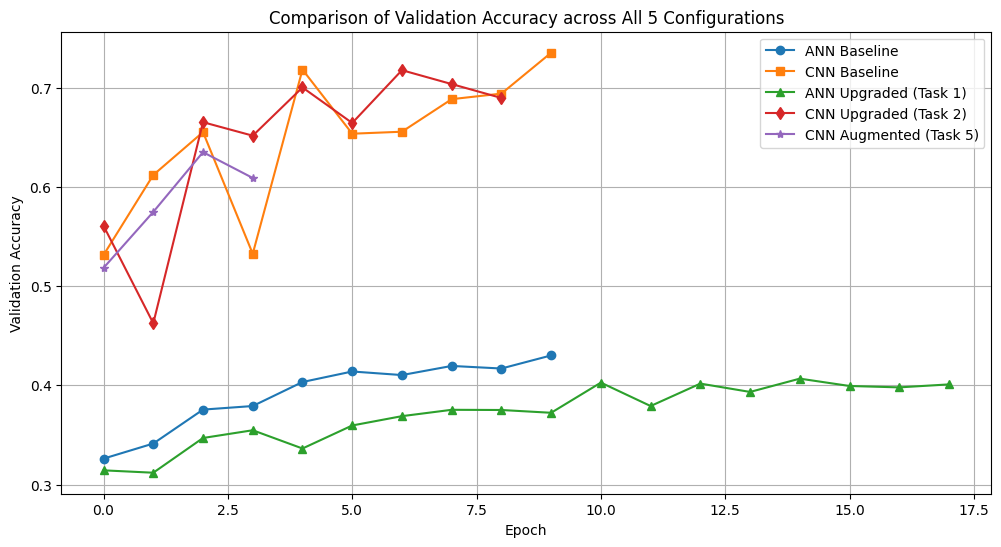

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(ann_history.history['val_accuracy'], label='ANN Baseline', marker='o')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Baseline', marker='s')
plt.plot(ann_upgraded_history.history['val_accuracy'], label='ANN Upgraded (Task 1)', marker='^')
plt.plot(cnn_upgraded_history.history['val_accuracy'], label='CNN Upgraded (Task 2)', marker='d')
plt.plot(cnn_augmented_history.history['val_accuracy'], label='CNN Augmented (Task 5)', marker='*')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Comparison of Validation Accuracy across All 5 Configurations")
plt.legend()
plt.grid(True)
plt.show()

# 📊 Final Comparison Table

In [ ]:
comparison_all = pd.DataFrame({
    "Model Variant": [
        "ANN Baseline",
        "CNN Baseline",
        "ANN Upgraded (Task 1)",
        "CNN Upgraded (Task 2)",
        "CNN Augmented (Task 5)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        ann_upg_acc,
        cnn_upg_acc,
        cnn_aug_acc
    ]
})
comparison_all["Test Accuracy (%)"] = comparison_all["Test Accuracy"] * 100
comparison_all

,Model Variant,Test Accuracy,Test Accuracy (%)
0,ANN Baseline,0.4355,43.550000
1,CNN Baseline,0.7173,71.730000
2,ANN Upgraded (Task 1),0.3929,39.289999
3,CNN Upgraded (Task 2),0.6934,69.340003
4,CNN Augmented (Task 5),0.5193,51.929998
